# Análisis de potencial de optimización por ciudad y barrio
### Sprint 3 — Analista de Marketing i Estratègia Comercial · 13/07/2026

Responde a: *¿qué ciudades y barrios presentan mayor potencial de
optimización considerando las reseñas, la puntuación de la zona y la
disponibilidad mínima/máxima de noches?*

## 1. Introducción: cómo vamos a proceder

De forma resumida, construimos un **índice compuesto (scorecard)** que
mide, para cada barrio, la distancia entre lo que **podría** rendir
(buena ubicación) y lo que rinde en las **palancas accionables**
(rating y fricción de noches). Ordenamos barrios y ciudades por ese
índice y nos quedamos con un Top para decidir las acciones.

**Puntos importantes del análisis (solo los nombramos aquí):**

1. Puntos de corte de cada variable, con su fuente.
2. Limpieza, normalización y **escalado** de variables a escalas
   comparables con las fuentes.
3. Rating ajustado por **media bayesiana** (número de reseñas).
4. Índice compuesto: fórmula, pesos y normalización.
5. Banderas legales (límite de 31 noches) reportadas aparte.
6. Ranking, filtrado a Top 10/5 y definición de *call to action*.

### 1.1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

### 1.2. Carga del dataset

> **_Pendiente: actualizar la ruta en cuanto tengamos el nuevo
> clean_dataset._** Ahora usamos `clean_dataset_06_07_2026.csv`
> (mismas columnas esperadas).

In [2]:
# ACTUALIZAR esta ruta con el nuevo clean_dataset cuando
# esté listo (se asume la misma estructura de columnas).
RUTA = "../Data/clean_dataset_06_07_2026.csv"
df = pd.read_csv(RUTA)
print("filas, columnas:", df.shape)

filas, columnas: (7693, 54)


In [3]:
# Solo las columnas que necesita el scorecard.
cols = [
    "apartment_id", "neighbourhood_name", "city", "country",
    "review_scores_rating", "review_scores_location",
    "minimum_nights", "maximum_nights",
    "number_of_reviews", "reviews_per_month",
    "first_review_date", "last_review_date",
]
data = df[cols].copy()
data.head()

,apartment_id,neighbourhood_name,city,country,review_scores_rating,review_scores_location,minimum_nights,maximum_nights,number_of_reviews,reviews_per_month,first_review_date,last_review_date
0,15695052,el Raval,Barcelona,spain,NaN,NaN,3,10,2,82.0,2016-10-26,2016-10-30
1,14999488,el Camp d'en Grassot i Gr�cia Nova,Barcelona,spain,90.0,10.0,1,30,2,65.0,2016-10-06,2016-12-27
2,12265320,la Vila Ol�mpica del Poblenou,Barcelona,spain,99.0,10.0,1,1125,22,272.0,2016-05-08,2016-12-27
3,16272738,el Baix Guinard�,Barcelona,spain,100.0,8.0,2,1125,1,10.0,2017-01-02,2017-01-02
4,16262996,el Raval,Barcelona,spain,NaN,NaN,1,1125,0,NaN,NaN,NaN


**Verificación del periodo temporal (2017-2020).** El marco legal se
ancla en 2017-2020, así que comprobamos las fechas de reseña.

In [4]:
for c in ["first_review_date", "last_review_date"]:
    data[c] = pd.to_datetime(data[c], errors="coerce")

print("first_review:", data["first_review_date"].min().date(),
      "->", data["first_review_date"].max().date())
print("last_review :", data["last_review_date"].min().date(),
      "->", data["last_review_date"].max().date())

first_review: 2010-01-02 -> 2020-10-24
last_review : 2012-11-17 -> 2021-02-13


> **_A decidir: los datos llegan hasta 2021, no solo 2017-2020._** No
> hay sustento para recortar la ventana sin más, así que de momento
> aplicamos el **marco regulatorio 2017-2020 como escenario**, no como
> fecha exacta del dato. Confirmar con el equipo si se filtra por fecha.

## 2. Decisiones sobre los puntos de corte

Cada variable de la pregunta tiene una **naturaleza distinta**, y eso
determina cómo la usamos. No todas se "optimizan" igual.

| Variable | Naturaleza | Rol | Corte |
|---|---|---|---|
| `review_scores_location` | Activo fijo | Filtro cualificador | Relativo (mediana) |
| `review_scores_rating` | Palanca | Brecha hasta el estándar | 4,8 (Superhost) |
| `minimum_nights` | Palanca | Fricción comercial | p75 por ciudad |
| `maximum_nights` | Restricción legal | Bandera aparte | 31 noches |

**Criterios y fuentes de cada corte:**

- **Rating → 4,8.** Es el umbral **Superhost** de Airbnb, con efecto
  medido: **+22% de reservas**. Por debajo de 4,8 hay recorrido de
  mejora = potencial. *(Fuente: Airbnb Superhost, help/article/829.)*
- **Ubicación → corte relativo.** No existe umbral académico absoluto;
  la ubicación es un driver mayor pero **inmóvil**, así que solo sirve
  para **cualificar** barrios (buena materia prima), no para puntuar
  mejora. Al estar muy sesgada, usamos un corte **relativo (mediana)**.
  *(Fuente: literatura hedónica, MDPI 2025.)*
- **Noches mínimas → banda óptima + percentil por ciudad.** Un mínimo
  de **3-4 noches ingresa +35-41%** que 1 noche (estudio de 4,1 M de
  anuncios), pero la cola alta (7, 14, 30) fragmenta el calendario. Por
  eso el corte es la **cola alta del comp-set: p75 por ciudad**, no la
  media cruda. *(Fuente: shorttermrentalz / Hostaway.)*
- **Noches > 31 → corte legal.** El límite turístico catalán de **31
  días** separa uso turístico de temporada. Se reporta como acción de
  **regularización**, no entra en el score. *(Fuente: Decreto 159/2012.)*

> **_Cortes provisionales (a fijar contra la distribución real):_** el
> corte exacto de **ubicación** (mediana vs tercil superior) y el de
> **`min_nights`** (p75 vs p90) se deciden mirando los datos en la
> sección 3. No hay un único valor "correcto".

## 3. Limpieza, normalización y escalado

Preparamos las variables según las decisiones anteriores y las
llevamos a escalas comparables con las fuentes.

In [5]:
palancas = [
    "review_scores_rating", "review_scores_location",
    "minimum_nights", "maximum_nights",
]
data[palancas].isna().sum()

review_scores_rating      1634
review_scores_location    1649
minimum_nights               0
maximum_nights               0
dtype: int64

In [6]:
# Sin rating o sin ubicación un anuncio no es puntuable.
antes = len(data)
data = data.dropna(
    subset=["review_scores_rating", "review_scores_location"]
)
print(antes, "->", len(data))

7693 -> 6044


**Escalado a escala 0-5.** En el dataset el `rating` viene en **0-100**
y la `location` en **0-10**; los referentes de Airbnb (4,8 Superhost)
están en **0-5**. Los llevamos todos a 0-5 para poder compararlos.

In [7]:
# rating 0-100  ->  /20  = escala 0-5
data["rating_0_5"] = data["review_scores_rating"] / 20

# location 0-10 ->  /2   = escala 0-5
data["location_0_5"] = data["review_scores_location"] / 2

data[["rating_0_5", "location_0_5"]].describe()

,rating_0_5,location_0_5
count,6044.000000,6044.000000
mean,4.598379,4.764891
std,0.442156,0.377334
min,1.000000,1.000000
25%,4.450000,4.500000
50%,4.700000,5.000000
75%,4.900000,5.000000
max,5.000000,5.000000


**Distribuciones** para fijar los cortes relativos (sección 2).

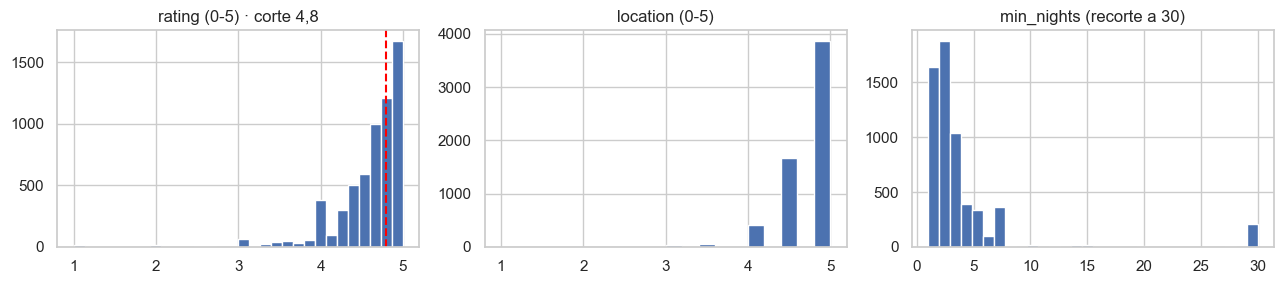

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
data["rating_0_5"].hist(bins=30, ax=ax[0])
ax[0].axvline(4.8, color="red", ls="--")
ax[0].set_title("rating (0-5) · corte 4,8")
data["location_0_5"].hist(bins=20, ax=ax[1])
ax[1].set_title("location (0-5)")
data["minimum_nights"].clip(upper=30).hist(bins=30, ax=ax[2])
ax[2].set_title("min_nights (recorte a 30)")
plt.tight_layout()
plt.show()

In [9]:
# Percentiles de min_nights por ciudad (comp-set).
p_ciudad = (
    data.groupby("city")["minimum_nights"]
    .quantile([0.5, 0.75, 0.9]).unstack()
)
p_ciudad.columns = ["p50", "p75", "p90"]
p_ciudad

,p50,p75,p90
city,,,
Barcelona,2.0,3.00,7.0
Girona,2.0,4.00,7.0
Madrid,2.0,3.00,4.0
Mallorca,4.0,6.00,7.0
Menorca,5.0,6.75,7.0
Málaga,2.0,3.00,4.0
Sevilla,2.0,2.00,3.0
Valencia,2.0,3.00,4.7


**Diagnóstico de `maximum_nights`.** Comprobamos el caveat: si casi
todo es el default de plataforma (365/1125), la variable **no
discrimina** barrios y solo vale como lista de regularización.

In [10]:
data["maximum_nights"].value_counts().head(5)

maximum_nights
1125    3558
30       402
1124     184
365      178
60       154
Name: count, dtype: int64

> **_Pendiente de verificar: `reviews_per_month` tiene valores raros_**
> (rango ~1 a 1273, mediana ~58), no parece "reseñas por mes" literal.
> Podría estar escalado. Lo usamos **solo como proxy relativo de
> demanda** en la validación, nunca como valor absoluto.

## 4. Parte estadística: la fórmula, explicada

**a) Rating ajustado por media bayesiana.** Un 5,0 con 2 reseñas no es
tan fiable como un 4,85 con 300. La media bayesiana **encoge** el
rating hacia la media de la ciudad cuando hay pocas reseñas:

$$Rating_{ajustado} = \frac{C \cdot m + n \cdot rating}{C + n}$$

- `m` = media de rating de la ciudad (a dónde tira si hay poca info).
- `n` = número de reseñas del anuncio (cuánta confianza tenemos).
- `C` = mediana de reseñas del dataset (cuánto pesa la media global).

*¿Por qué estos valores?* `C` = mediana de reseñas es el estándar (el
Top-250 de IMDb usa el mismo método): un anuncio con reseñas por encima
de la mediana ya "manda" su propia nota; por debajo, se apoya en la
media de la ciudad. No usamos la media de reseñas porque está inflada
por unos pocos anuncios con cientos.

In [11]:
# m = media de rating por ciudad; C = mediana de reseñas.
m = data.groupby("city")["rating_0_5"].transform("mean")
C = data["number_of_reviews"].median()
n = data["number_of_reviews"].fillna(0)

data["rating_bayes"] = (C * m + n * data["rating_0_5"]) / (C + n)
print("C (mediana de reseñas):", C)
data[["rating_0_5", "number_of_reviews", "rating_bayes"]].head()

C (mediana de reseñas): 15.0


,rating_0_5,number_of_reviews,rating_bayes
1,4.50,2,4.531003
2,4.95,22,4.781812
3,5.00,1,4.564191
6,4.00,2,4.472179
7,4.15,13,4.356323


**b) Sub-scores de potencial (las dos brechas).** El potencial es la
distancia entre lo alcanzable y lo actual, solo en la dirección
"mejorable" (por eso recortamos en 0 con `clip`):

- **Brecha de rating** = cuánto le falta al rating bayesiano para 4,8.
- **Fricción de noches** = cuánto excede `min_nights` el umbral (p75)
  de su ciudad.

*¿Por qué 4,8 y p75, y no otros?* 4,8 es el umbral **observable** con
efecto en demanda (Superhost, +22%); no es arbitrario. p75 por ciudad
marca la **cola restrictiva relativa al comp-set** local, que es lo que
de verdad frena reservas, en vez de un número fijo igual para todas.

In [12]:
OBJETIVO_RATING = 4.8  # umbral Superhost

# Umbral de min_nights: p75 de cada ciudad.
umbral = (
    data.groupby("city")["minimum_nights"]
    .transform(lambda s: s.quantile(0.75))
)
data["umbral_min_nights"] = umbral

In [13]:
data["brecha_rating"] = (
    (OBJETIVO_RATING - data["rating_bayes"]).clip(lower=0)
)
data["friccion_noches"] = (
    (data["minimum_nights"] - data["umbral_min_nights"])
    .clip(lower=0)
)
data[["brecha_rating", "friccion_noches"]].describe()

,brecha_rating,friccion_noches
count,6044.000000,6044.000000
mean,0.188456,1.746691
std,0.148743,10.711513
min,0.000000,0.000000
25%,0.079608,0.000000
50%,0.164703,0.000000
75%,0.268997,0.000000
max,1.063563,362.000000


**c) Banderas legales (capa de regularización).** Se reportan aparte,
no entran en el score continuo.

In [14]:
data["cumple_limite_31d"] = data["maximum_nights"] <= 31
data["incumple_min_31"] = data["minimum_nights"] > 31
data[["cumple_limite_31d", "incumple_min_31"]].mean()

cumple_limite_31d    0.207313
incumple_min_31      0.019523
dtype: float64

## 5. Recopilación de resultados y filtrado

Agregamos a nivel barrio, aplicamos filtros de fiabilidad y de
ubicación, calculamos el índice compuesto y nos quedamos con un Top.

**Paso 1 — Muestra mínima por barrio.** Descartamos barrios con pocos
anuncios (poco fiables). Regla provisional: quitar el **cuartil
inferior** de tamaños.

> **_A decidir: la muestra mínima (cuartil inferior vs un fijo tipo
> 20)._** No hay un único criterio; se ajusta con negocio.

In [15]:
tam = data.groupby(["city", "neighbourhood_name"]).size()
corte_tam = tam.quantile(0.25)
print("corte de muestra mínima:", corte_tam)

corte de muestra mínima: 1.0


**Paso 2 — Agregar a nivel barrio.** Promediamos las brechas, el % a
regularizar y la demanda (proxy relativo).

In [16]:
g = data.groupby(["city", "neighbourhood_name"])
barrio = g.agg(
    n_anuncios=("apartment_id", "size"),
    location_0_5=("location_0_5", "mean"),
    brecha_rating=("brecha_rating", "mean"),
    friccion_noches=("friccion_noches", "mean"),
    pct_regularizar=("incumple_min_31", "mean"),
    demanda=("reviews_per_month", "median"),
).reset_index()

barrio = barrio[barrio["n_anuncios"] >= corte_tam]
print("barrios tras muestra mínima:", len(barrio))

barrios tras muestra mínima: 469


**Paso 3 — Filtro cualificador de ubicación.** Solo pasan barrios con
buena ubicación (por encima de la mediana). Es "materia prima" buena
para justificar la inversión en optimización.

> **_Provisional: corte de ubicación en la mediana._** Podría subirse
> al tercil superior si quedan demasiados candidatos.

In [17]:
corte_loc = barrio["location_0_5"].median()
cand = barrio[barrio["location_0_5"] >= corte_loc].copy()
print(len(barrio), "->", len(cand), "candidatos")

469 -> 237 candidatos


**Paso 4 — Normalizar los sub-scores.** Llevamos las dos brechas a 0-1
(min-max) para poder sumarlas en la misma escala.

> **_A documentar: usamos min-max; la alternativa sería z-score._**

In [18]:
def min_max(s):
    rango = s.max() - s.min()
    if rango == 0:
        return s * 0
    return (s - s.min()) / rango

cand["n_rating"] = min_max(cand["brecha_rating"])
cand["n_noches"] = min_max(cand["friccion_noches"])

**Paso 5 — Índice compuesto.** Combinamos las dos palancas con pesos.

$$Potencial(b) = w_r \cdot n\_rating(b) + w_m \cdot n\_noches(b)$$

> **_Pesos de arranque 0,5 / 0,5 (a validar con análisis de
> sensibilidad)._** Si negocio prioriza una palanca, se justifica y
> se recalcula.

In [19]:
W_RATING = 0.5
W_NOCHES = 0.5

cand["potencial"] = (
    W_RATING * cand["n_rating"]
    + W_NOCHES * cand["n_noches"]
)

**Paso 6 — Ranking de barrios (Top 10).**

In [20]:
top = cand.sort_values("potencial", ascending=False)
top10 = top.head(10)
top10[[
    "city", "neighbourhood_name", "n_anuncios",
    "location_0_5", "brecha_rating", "friccion_noches",
    "pct_regularizar", "potencial",
]].round(3)

,city,neighbourhood_name,n_anuncios,location_0_5,brecha_rating,friccion_noches,pct_regularizar,potencial
58,Barcelona,la Sagrera,1,5.000,0.210,28.000,0.000,0.803
223,Madrid,Goya,17,4.882,0.182,21.824,0.059,0.651
5,Barcelona,Hostafrancs,27,4.704,0.341,2.852,0.074,0.541
422,Valencia,EL GRAU,5,4.700,0.145,17.400,0.200,0.520
46,Barcelona,la Barceloneta,30,4.933,0.240,9.567,0.233,0.516
409,Valencia,BENIMACLET,3,5.000,0.347,0.000,0.000,0.500
423,Valencia,EL MERCAT,15,4.933,0.267,5.333,0.000,0.479
446,Valencia,LA XEREA,9,5.000,0.196,10.889,0.111,0.477
43,Barcelona,el Raval,136,4.713,0.269,4.272,0.088,0.464
17,Barcelona,"Sant Pere, Santa Caterina i la Ribera",116,4.944,0.246,5.233,0.121,0.448


**Paso 7 — Ranking de ciudades.** Respondemos también al "qué ciudad".

In [21]:
ciudad = (
    cand.groupby("city")["potencial"]
    .mean().sort_values(ascending=False)
)
ciudad.round(3)

city
Barcelona    0.378
Málaga       0.304
Valencia     0.248
Girona       0.243
Madrid       0.216
Menorca      0.199
Sevilla      0.183
Mallorca     0.159
Name: potencial, dtype: float64

**Paso 8 — Análisis de sensibilidad de los pesos.** Vemos si el Top 5
aguanta al mover el peso del rating (robustez del ranking).

In [22]:
for wr in [0.3, 0.5, 0.7]:
    p = wr * cand["n_rating"] + (1 - wr) * cand["n_noches"]
    idx = p.sort_values(ascending=False).head(5).index
    nombres = cand.loc[idx, "neighbourhood_name"].tolist()
    print("w_rating", wr, "->", nombres)

w_rating 0.3 -> ['la Sagrera', 'Goya', 'EL GRAU', 'la Barceloneta', 'LA XEREA']
w_rating 0.5 -> ['la Sagrera', 'Goya', 'Hostafrancs', 'EL GRAU', 'la Barceloneta']
w_rating 0.7 -> ['la Sagrera', 'Hostafrancs', 'BENIMACLET', 'Puigcerd�', 'Goya']


**Paso 9 — Top 5 final y capa de regularización.**

In [23]:
top5 = top.head(5).copy()
top5["pct_regularizar"] = (top5["pct_regularizar"] * 100).round(1)
top5[[
    "city", "neighbourhood_name", "potencial",
    "brecha_rating", "friccion_noches", "pct_regularizar",
]].round(3)

,city,neighbourhood_name,potencial,brecha_rating,friccion_noches,pct_regularizar
58,Barcelona,la Sagrera,0.803,0.210,28.000,0.0
223,Madrid,Goya,0.651,0.182,21.824,5.9
5,Barcelona,Hostafrancs,0.541,0.341,2.852,7.4
422,Valencia,EL GRAU,0.520,0.145,17.400,20.0
46,Barcelona,la Barceloneta,0.516,0.240,9.567,23.3


### 5.1. Call to action (borrador)

A partir del Top, cada barrio se traduce en una acción según de dónde
venga su potencial:

- **Alta `brecha_rating`** → plan de mejora de calidad/servicio para
  acercarse al umbral **4,8** (Superhost, +22% reservas).
- **Alta `friccion_noches`** → revisar la estancia mínima; bajarla
  hacia la banda óptima **3-4 noches** reduce fragmentación de calendario.
- **Alto `pct_regularizar`** → acción legal: revisar anuncios con
  `min_nights > 31` (fuera del régimen turístico de 31 días).

> **_Pendientes antes de cerrar los call to action:_** confirmar
> pesos, cortes y muestra mínima (secciones 2, 3 y 5), verificar
> `reviews_per_month`, y cruzar con la **validación IPA + residuos**
> del 13/07 para triangular los barrios top.